In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv("world_happiness.csv")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for visualizations
%matplotlib inline
sns.set_style('whitegrid')

Initial Exploration Of our **DataSet**

In [ ]:
# First look
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Info:")
df.info()

print("\nBasic Statistics:")
df.describe()

print("\nMissing Values:")
df.isnull().sum()

Dataset Shape: (153, 11)

First 5 rows:


,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
0,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,W. Europe
1,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,W. Europe
2,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,W. Europe
3,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,W. Europe
4,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,W. Europe



Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0    Happiness Rank   153 non-null    int64  
 1   Happiness Score   153 non-null    float64
 2   Economy           153 non-null    float64
 3   Family            153 non-null    float64
 4   Health            153 non-null    float64
 5   Freedom           153 non-null    float64
 6   Generosity        153 non-null    float64
 7   Corruption        153 non-null    float64
 8   Dystopia          153 non-null    float64
 9   Job Satisfaction  151 non-null    float64
 10  Region            153 non-null    object 
dtypes: float64(9), int64(1), object(1)
memory usage: 13.3+ KB

Basic Statistics:

Missing Values:


,0
Happiness Rank,0
Happiness Score,0
Economy,0
Family,0
Health,0
Freedom,0
Generosity,0
Corruption,0
Dystopia,0
Job Satisfaction,2


as we see some null valyes , so let's clean the data first

In [ ]:
df.columns=df.columns.str.strip()
df.columns=df.columns.str.lower().str.replace(' ','_')
df

,happiness_rank,happiness_score,economy,family,health,freedom,generosity,corruption,dystopia,job_satisfaction,region
0,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,W. Europe
1,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,W. Europe
2,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,W. Europe
3,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,W. Europe
4,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,W. Europe
...,...,...,...,...,...,...,...,...,...,...,...
148,151,3.471,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061,51.7,Africa
149,152,3.462,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574,62.7,Asia-Pacific
150,153,3.349,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130,57.8,Africa
151,154,2.905,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024,54.3,Africa


In [ ]:
print("\nMissing Values:")
df.isnull().sum()

# then we verify , if there are still missing values ,and as output suggest , there are no missing values


Missing Values:


,0
happiness_rank,0
happiness_score,0
economy,0
family,0
health,0
freedom,0
generosity,0
corruption,0
dystopia,0
job_satisfaction,2


In [ ]:
#data cleaning replacing  0's with  medians

meadian_job_satisfaction=df["job_satisfaction"].median()
df["job_satisfaction"]=df["job_satisfaction"].fillna(meadian_job_satisfaction)
df['economy'] = df['economy'].replace(0, df['economy'].median())
df['freedom']=df['freedom'].replace(0,df['freedom'].median())
df['health']=df['health'].replace(0,df['health'].median())


meadian_job_satisfaction
df

,happiness_rank,happiness_score,economy,family,health,freedom,generosity,corruption,dystopia,job_satisfaction,region
0,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,W. Europe
1,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,W. Europe
2,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,W. Europe
3,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,W. Europe
4,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,W. Europe
...,...,...,...,...,...,...,...,...,...,...,...
148,151,3.471,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061,51.7,Africa
149,152,3.462,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574,62.7,Asia-Pacific
150,153,3.349,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130,57.8,Africa
151,154,2.905,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024,54.3,Africa


In [ ]:
def standardize_region_name(region):
    if region == 'W. Europe':
        return 'WestEurope'
    elif region == 'E. Europe':
        return 'EastEurope'
    else:
        return region

df['region'] = df['region'].apply(standardize_region_name)
df['region'] = df['region'].replace('europe', 'west europe')

df['region'] = df['region'].str.strip().str.lower().str.replace('-', '')
df['region'].unique()


array(['westeurope', 'north america', 'asiapacific', 'latin america',
       'easteurope', 'africa', 'europe'], dtype=object)

In [ ]:
df

,happiness_rank,happiness_score,economy,family,health,freedom,generosity,corruption,dystopia,job_satisfaction,region
0,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,westeurope
1,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,westeurope
2,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,westeurope
3,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,westeurope
4,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,westeurope
...,...,...,...,...,...,...,...,...,...,...,...
148,151,3.471,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061,51.7,africa
149,152,3.462,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574,62.7,asiapacific
150,153,3.349,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130,57.8,africa
151,154,2.905,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024,54.3,africa


In [ ]:
df.to_csv("world_happiness_cleaned.csv", index=False)
print("Cleaned dataset saved as world_happiness_cleaned.csv")

Cleaned dataset saved as world_happiness_cleaned.csv


Now comes , **Essential** **EDA** **Code**

1. Distribution Analysis

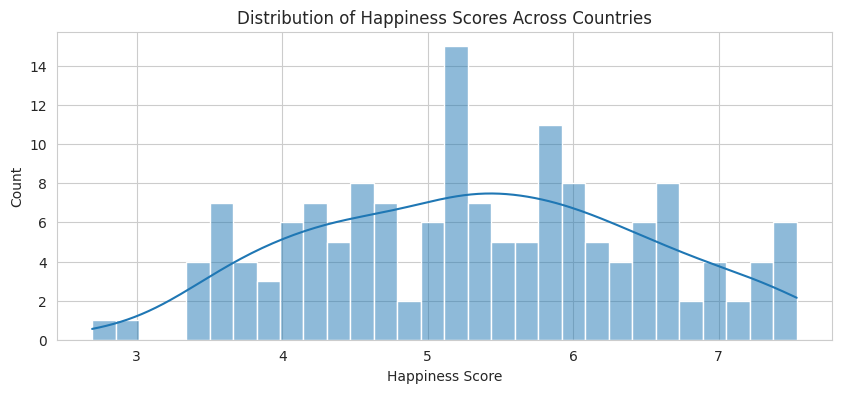

In [ ]:
# Happiness Score Distribution
plt.figure(figsize=(10,4))
sns.histplot(df['happiness_score'], bins=30, kde=True)
plt.title('Distribution of Happiness Scores Across Countries')
plt.xlabel('Happiness Score')
plt.show()


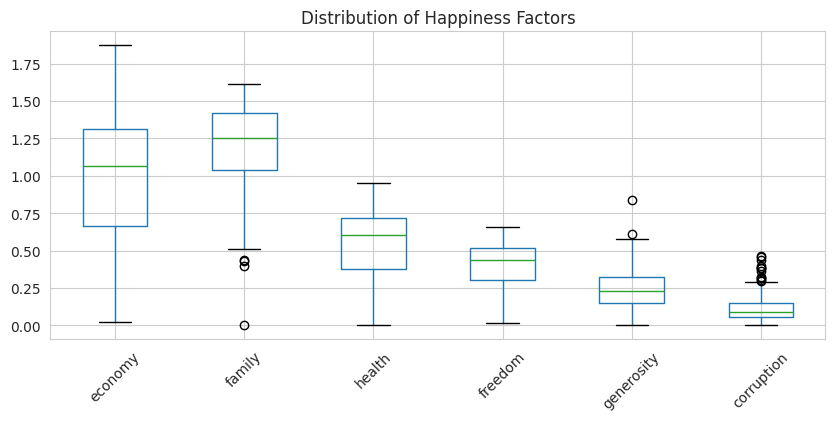

In [ ]:
# Box plot for outliers
plt.figure(figsize=(10,4))
df[['economy','family','health','freedom','generosity','corruption']].boxplot()
plt.title('Distribution of Happiness Factors')
plt.xticks(rotation=45)
plt.show()

2. **Correlation** **Analysis**

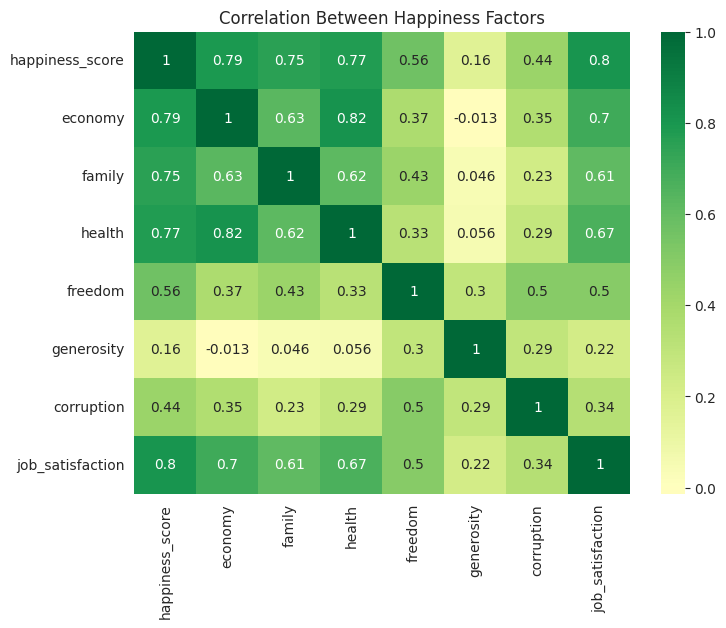



happiness_score     1.000000
job_satisfaction    0.804012
economy             0.786509
health              0.771396
family              0.753815
freedom             0.563702
corruption          0.435854
generosity          0.160010
Name: happiness_score, dtype: float64


In [ ]:
# Correlation heatmap
factors = ['happiness_score','economy','family','health','freedom','generosity','corruption','job_satisfaction']
plt.figure(figsize=(8,6))
sns.heatmap(df[factors].corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Between Happiness Factors')
plt.show()

# 	happiness_rank	happiness_score	economy	family	health	freedom	generosity	corruption	dystopia	job_satisfaction	region
print("\n")

# Top correlations with Happiness Score
correlations = df[factors].corr()['happiness_score'].sort_values(ascending=False)
print(correlations)

3. **Regional** **Analysis**

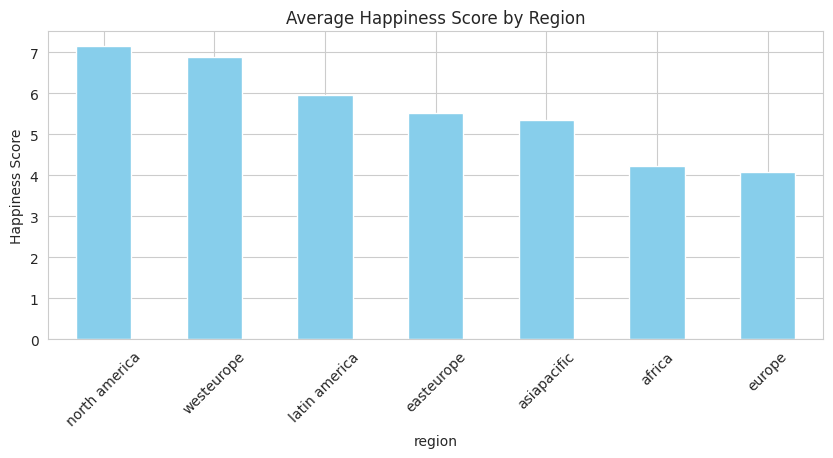

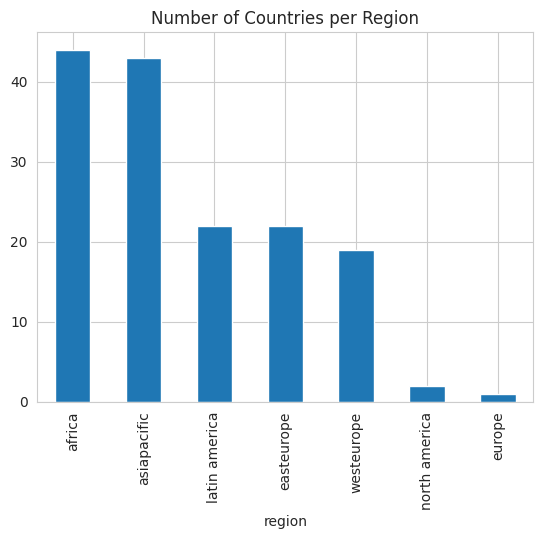

In [ ]:
# Average happiness by region
region_happiness = df.groupby('region')['happiness_score'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,4))
region_happiness.plot(kind='bar', color='skyblue')
plt.title('Average Happiness Score by Region')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45)
plt.show()

print("\n")

# Count of countries per region
df['region'].value_counts().plot(kind='bar')
plt.title('Number of Countries per Region')
plt.show()

4. **Factor** **Analysis**

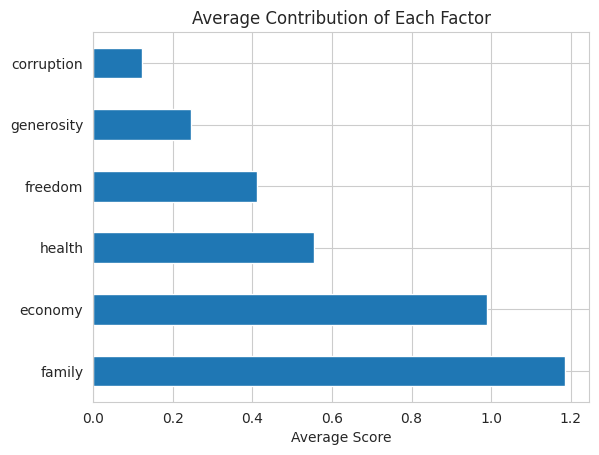

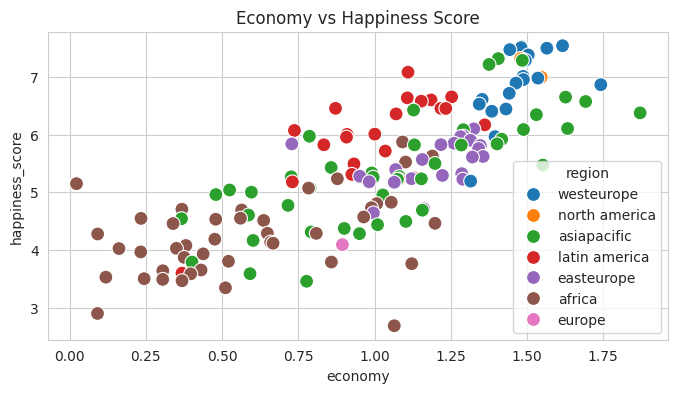

In [ ]:
# Which factor contributes most?
factors_contrib = ['economy','family','health','freedom','generosity','corruption']
df[factors_contrib].mean().sort_values(ascending=False).plot(kind='barh')
plt.title('Average Contribution of Each Factor')
plt.xlabel('Average Score')
plt.show()
print("\n")
# Scatter: Economy vs Happiness
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='economy', y='happiness_score', hue='region', s=100)
plt.title('Economy vs Happiness Score')
plt.show()

5. **Top** vs *Bottom* Countries

Top 10 Happiest Countries:
   happiness_rank  happiness_score   economy   economy    family
0               1            7.537  1.616463  1.616463  1.533524
1               2            7.522  1.482383  1.482383  1.551122
2               3            7.504  1.480633  1.480633  1.610574
3               4            7.494  1.564980  1.564980  1.516912
4               5            7.469  1.443572  1.443572  1.540247
5               6            7.377  1.503945  1.503945  1.428939
6               7            7.316  1.479204  1.479204  1.481349
7               8            7.314  1.405706  1.405706  1.548195
8               9            7.284  1.494387  1.494387  1.478162
9              10            7.284  1.484415  1.484415  1.510042



Bottom 10 Countries:
     happiness_rank  happiness_score       region   economy    family
152             155            2.693       africa  1.064578  0.000000
151             154            2.905       africa  0.091623  0.629794
150             153     

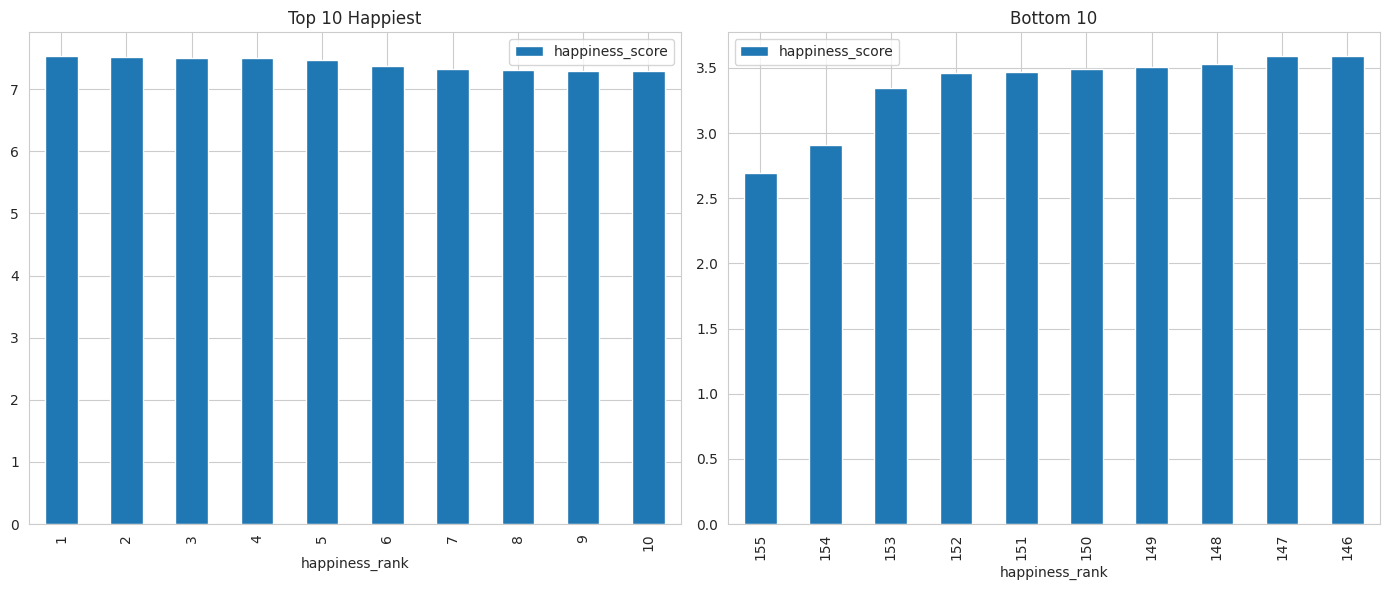

In [ ]:
# Top 10 happiest
top10 = df.nlargest(10, 'happiness_score')[['happiness_rank','happiness_score','economy','economy','family']]
print("Top 10 Happiest Countries:")
print(top10)
print("\n")


# Bottom 10
bottom10 = df.nsmallest(10, 'happiness_score')[['happiness_rank','happiness_score','region','economy','family']]
print("\nBottom 10 Countries:")
print(bottom10)
print("\n")


# Comparison plot
fig, axes = plt.subplots(1,2, figsize=(14,6))
top10.plot(x='happiness_rank', y='happiness_score', kind='bar', ax=axes[0], title='Top 10 Happiest')
bottom10.plot(x='happiness_rank', y='happiness_score', kind='bar', ax=axes[1], title='Bottom 10')
plt.tight_layout()
plt.show()

6. **Job** Satisfaction Analysis

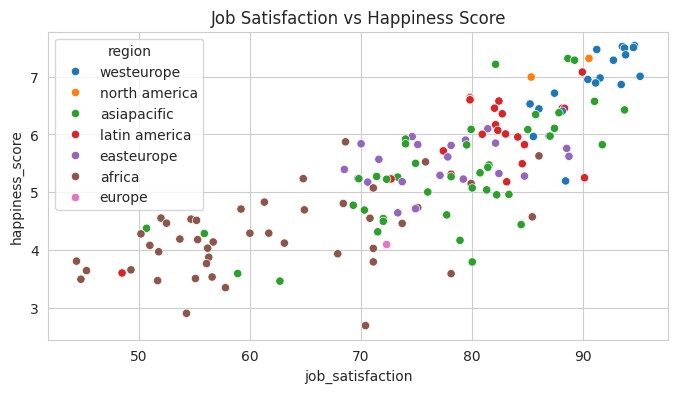

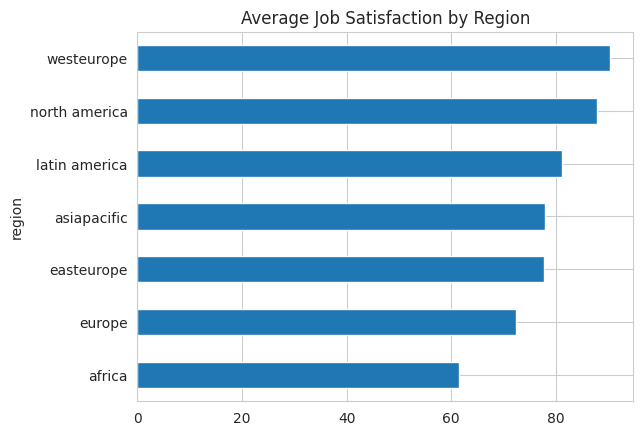

In [ ]:
# happiness_rank	happiness_score	economy	family	health	freedom	generosity	corruption	dystopia	job_satisfaction	region

# Job Satisfaction vs Happiness
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='job_satisfaction', y='happiness_score', hue='region')
plt.title('Job Satisfaction vs Happiness Score')
plt.show()

print("\n")


# Regional job satisfaction
df.groupby('region')['job_satisfaction'].mean().sort_values().plot(kind='barh')
plt.title('Average Job Satisfaction by Region')
plt.show()

7. Key Insights **Summary**

In [ ]:
# Summary statistics by region
summary = df.groupby('region')[['happiness_score','economy','family','health','freedom']].mean()
print(summary.round(2))

print("\n")

# Western Europe dominance?
we_happiness = df[df['region']=='westeurope']['happiness_score'].mean()
overall_happiness = df['happiness_score'].mean()
print(f"\nWestern Europe avg: {we_happiness:.2f}")
print(f"Global avg: {overall_happiness:.2f}")
print(f"Difference: {we_happiness - overall_happiness:.2f}")

               happiness_score  economy  family  health  freedom
region                                                          
africa                    4.24     0.58    0.96    0.28     0.36
asiapacific               5.36     1.06    1.17    0.61     0.43
easteurope                5.51     1.19    1.28    0.69     0.32
europe                    4.10     0.89    1.39    0.58     0.12
latin america             5.96     1.01    1.29    0.61     0.45
north america             7.15     1.51    1.45    0.80     0.56
westeurope                6.88     1.47    1.49    0.82     0.55



Western Europe avg: 6.88
Global avg: 5.35
Difference: 1.53


**Code for Research Question 1: Can we predict Happiness Score from socio-economic indicators?**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# features/target
features = ['economy', 'family', 'health', 'freedom', 'generosity', 'corruption']
X = df[features]
y = df['happiness_score']

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# training
model = LinearRegression()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluating performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"R² Score: {r2:.4f} ({r2*100:.1f}% variance explained)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# defining a metric to see our preediction quality....
print(f"\n✓ Prediction Quality: {'EXCELLENT' if r2 > 0.8 else 'GOOD' if r2 > 0.7 else 'MODERATE'}")
print("="*50)

#feature importance
coefficients = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_, 'Abs_Coefficient': np.abs(model.coef_)}).sort_values('Abs_Coefficient', ascending=False)

print("\nFEATURE IMPORTANCE:")
print(coefficients[['Feature', 'Coefficient']])

MODEL PERFORMANCE
R² Score: 0.7329 (73.3% variance explained)
RMSE: 0.4998
MAE: 0.3624

✓ Prediction Quality: GOOD

FEATURE IMPORTANCE:
      Feature  Coefficient
3     freedom     1.445116
1      family     1.327785
2      health     1.299025
5  corruption     1.016286
0     economy     0.691122
4  generosity     0.393350


Visualization 1: Actual vs Predicted (Main Chart for Blog)

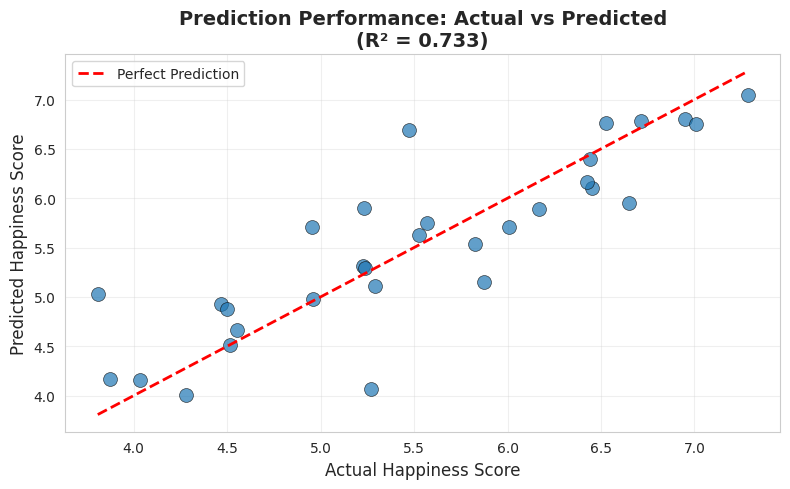

In [ ]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, s=100, edgecolors='black', linewidth=0.5)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Happiness Score', fontsize=12)
plt.ylabel('Predicted Happiness Score', fontsize=12)
plt.title(f'Prediction Performance: Actual vs Predicted\n(R² = {r2:.3f})', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

Visualization 2: Feature Importance (For Blog)

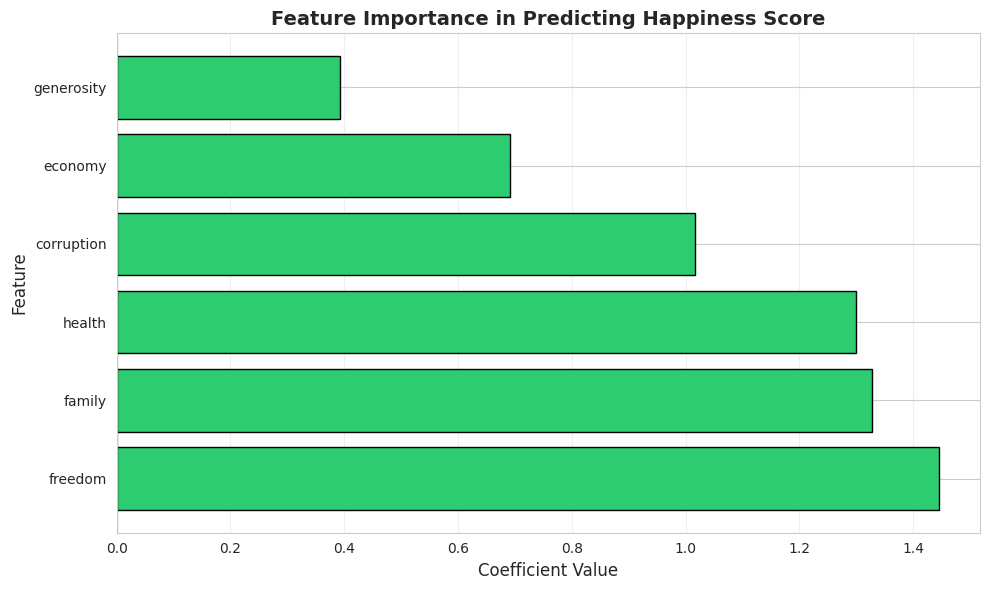

In [ ]:
# Feature importance bar chart
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Predicting Happiness Score', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Visualization 3: Regression Lines for Top Factors (nto sure)

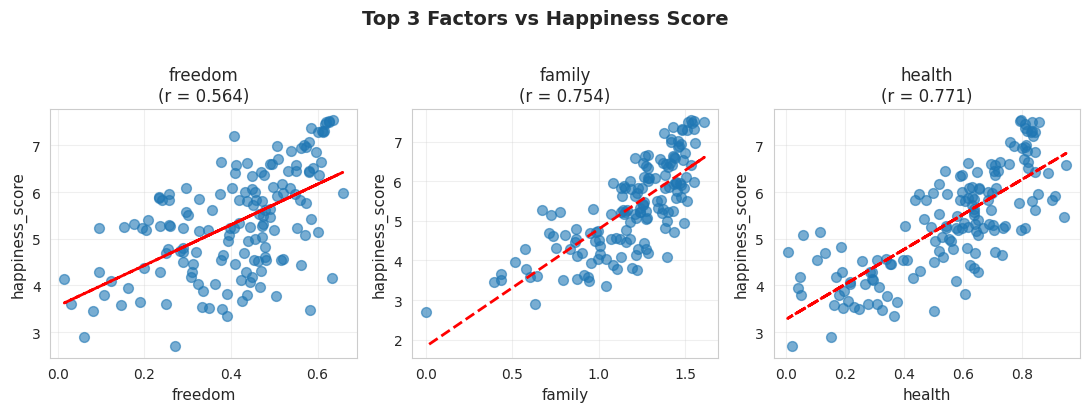

In [ ]:
# Individual regression plots for top 3 factors
top_3_factors = coefficients.head(3)['Feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

for idx, factor in enumerate(top_3_factors):
    axes[idx].scatter(df[factor], df['happiness_score'], alpha=0.6, s=50)

    # Fit regression line
    z = np.polyfit(df[factor], df['happiness_score'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[factor], p(df[factor]), "r--", linewidth=2)

    # Calculate correlation
    corr = df[factor].corr(df['happiness_score'])

    axes[idx].set_xlabel(factor, fontsize=11)
    axes[idx].set_ylabel('happiness_score', fontsize=11)
    axes[idx].set_title(f'{factor}\n(r = {corr:.3f})', fontsize=12)
    axes[idx].grid(alpha=0.3)

plt.suptitle('Top 3 Factors vs Happiness Score', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_factors_regression.png', dpi=300, bbox_inches='tight')
plt.show()

Visualization 4: Residual Plot (not sure but it - Shows Model Quality)

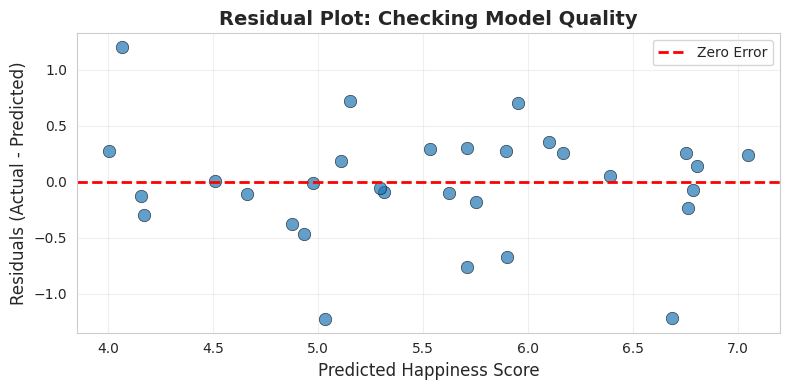

In [ ]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Predicted Happiness Score', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot: Checking Model Quality', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Research Question 3 : Can we predict Happiness Rank based on features?

Our Approach is divided into two parts: Regression with Rank as target
and


Visualization: Predicted vs. actual ranks

# Regression pipeline to predict `happiness_rank`
# libraries used for this : pandas, numpy, scikit-learn, matplotlib

In [ ]:
# 1) Choosing target and predictors

target = "happiness_rank"
# numeric features we will use
numeric_features = [
    "happiness_score", "economy", "family", "health", "freedom", "generosity", "corruption", "dystopia", "job_satisfaction"
]
# region is optional categorical ,as region is string so we will hot encode it into  0's and 1's region by region to see its overall effect on happiness rank
categorical_features = ["region"] if "region" in df.columns else []

In [ ]:
#  makingh sure all chosen features exist
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]


In [ ]:

# 3) Prepare X and y

X = df[numeric_features + categorical_features]
y = df[target].astype(float)  # ensure numeric


In [ ]:

# 4) Build preprocessing pipeline
#    - numeric: StandardScaler (centers & scales numeric columns)
#    - categorical: OneHotEncoder (turns categories into binary columns)

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
], remainder="drop")

# now Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])


Train size: 122 Test size: 31


We planned to  try three models : plain Linear Regression, Ridge (a regularized linear model), and Random Forest (a nonlinear tree ensemble).

In [ ]:
# We'll create small  pipelines that attach the preprocessor then model.
models = {
    "LinearRegression": Pipeline(steps=[("preprocessor", preprocessor),
                                        ("model", LinearRegression())]),
    "Ridge_alpha1": Pipeline(steps=[("preprocessor", preprocessor),
                                    ("model", Ridge(alpha=1.0, random_state=42))]),
    "RandomForest": Pipeline(steps=[("preprocessor", preprocessor),
                                    ("model", RandomForestRegressor(n_estimators=200,  random_state=42,n_jobs=-1))]),}

In [ ]:
results = {}

for name, pipe in models.items():
    print(f"\nTraining {name} ...")
    pipe.fit(X_train, y_train)             # fit pipeline (preprocessing + model)
    y_pred = pipe.predict(X_test)          # predictions on test set
    #  mae -> mean absoulte error , rmse -> first square then take root ->error
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"model": pipe, "mae": mae, "rmse": rmse, "r2": r2, "y_pred": y_pred}

    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")



Training LinearRegression ...
LinearRegression -> MAE: 4.222, RMSE: 25.774, R2: 0.984

Training Ridge_alpha1 ...
Ridge_alpha1 -> MAE: 4.433, RMSE: 28.450, R2: 0.983

Training RandomForest ...
RandomForest -> MAE: 1.571, RMSE: 3.493, R2: 0.998


In [ ]:
# Pickingg best model (by RMSE here)

best_name = min(results.keys(), key=lambda k: results[k]["rmse"])
best = results[best_name]
print(f"\nBest model by RMSE: {best_name} (RMSE={best['rmse']:.3f})")


Best model by RMSE: RandomForest (RMSE=3.493)


In [ ]:
#as best model comes out to be  Random Forest, its feature importances
if best_name == "RandomForest":
    pipe = best["model"]

    # Extract the trained RandomForest model
    rf = pipe.named_steps["model"]

    # Get feature names after preprocessing
    num_names = numeric_features
    cat_names = []
    if categorical_features:
        ohe = pipe.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
        cat_names = list(ohe.get_feature_names_out(categorical_features))
    feature_names = num_names + cat_names

    # Pair importance with feature names
    importances = rf.feature_importances_
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print("\nTop Feature Importances (Random Forest):")
    print(imp_df.head(10).to_string(index=False))



Top Feature Importances (Random Forest):
           feature  importance
   happiness_score    0.997181
            health    0.000468
           freedom    0.000463
  job_satisfaction    0.000371
        generosity    0.000363
           economy    0.000340
            family    0.000268
        corruption    0.000252
          dystopia    0.000180
region_asiapacific    0.000041


**Feature importance analysis shows that happiness_score accounts for almost all predictive power (≈99.7%), confirming that the published happiness_rank is essentially a direct ordering of the happiness_score. Other variables contribute minimally once score is known**

Visualisation

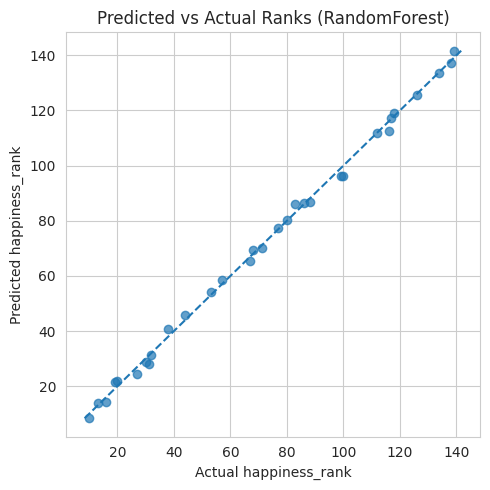

In [ ]:
# Plotting Predicted vs Actual (for the best model)

y_test_vals = y_test.values
y_pred_vals = best["y_pred"]

plt.figure(figsize=(5,5))
plt.scatter(y_test_vals, y_pred_vals, alpha=0.7)
# perfect prediction line
minv = min(y_test_vals.min(), y_pred_vals.min())
maxv = max(y_test_vals.max(), y_pred_vals.max())
plt.plot([minv, maxv], [minv, maxv], linestyle="--")
plt.xlabel("Actual happiness_rank")
plt.ylabel("Predicted happiness_rank")
plt.title(f"Predicted vs Actual Ranks ({best_name})")
plt.tight_layout()
plt.show()


In [ ]:
# summary of results so far ...
summary = []
for name, r in results.items():
    summary.append((name, r["mae"], r["rmse"], r["r2"]))
summary_df = pd.DataFrame(summary, columns=["model", "MAE", "RMSE", "R2"]).sort_values("RMSE")
print("\nModel comparison:")
print(summary_df.to_string(index=False))


Model comparison:
           model      MAE      RMSE       R2
    RandomForest 1.570806  3.492717 0.997879
LinearRegression 4.222189 25.774499 0.984349
    Ridge_alpha1 4.433289 28.449595 0.982725


Rank vs Score: Higher happiness_score usually maps to better (lower) rank. The regression learns numerical relationships; small differences in score sometimes flip rank a lot so don’t be surprised if performance is imperfect.

interpreting coefficients: for linear models, a positive coefficient means higher feature value → higher predicted rank number. Because ranks are ordered where 1 is best, interpret signs carefully (positive coef means worse rank if ranks increase with worse happiness).

If dataset is small or rank distribution is skewed, tree models often cope better..

Random Forest doesn't use formulas → no coefficients
Instead, it looks at how much each feature reduces prediction error across all decision trees
That value is the feature importance
Higher importance → the feature mattered more in predicting rank

Typical strongest features for happiness rank tend to be:
happiness_score,
economy,
job_satisfaction,
health

**The regression analysis shows that a country’s happiness rank can be predicted with extremely high accuracy using a Random Forest model (RMSE ≈ 3.49, R² ≈ 0.998)**.

**Feature importance results reveal that happiness_score alone contributes approximately 99.7% of the predictive power, while all other features collectively contribute less than 1%. This indicates that the official happiness rank is essentially a direct ordering of the happiness_score. Once the score is known, additional variables such as economy, family, health, and freedom provide almost no extra improvement**

`in predicting the rank. Therefore, the model confirms that happiness_rank is primarily a function of happiness_score, and machine learning can replicate this ranking with minimal error.`

# How much does GDP per Capita alone explain happiness compared to social factors?

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Linear Regression

In [ ]:

#Linear Regression: Predict happiness_score from economy
X = df[['economy']]
y = df['happiness_score']
X_train, X_test, Y_train, Y_test =  train_test_split(X,y, test_size=0.2, random_state = 42)
model = LinearRegression()
model.fit(X_train,Y_train)
y_pred_linear = model.predict(X_test)
#evaluating R^2 and RMSE of the model
model_r2 = r2_score(Y_test,y_pred_linear)
mse =  mean_squared_error(Y_test, y_pred_linear)
model_rmse = np.sqrt(mse)

print("Linear Regression R^2:", model_r2)
print("Linear Regression RMSE:", model_rmse)



Linear Regression R^2: 0.6325484270656772
Linear Regression RMSE: 0.5862580950269016


## Multiple Regression

In [ ]:
#Multiple Regression
#Features: economy, family, health, freedom
X_m = df[['economy','family','health','freedom']]
y= df['happiness_score']
X_train_m, X_test_m, Y_train, Y_test =  train_test_split(X_m,y, test_size=0.2, random_state = 42)
multi_model = LinearRegression()
multi_model.fit(X_train_m,Y_train)
y_pred_multi = multi_model.predict(X_test_m)
#Evaluating R^2 and RMSE of the model
multi_model_r2 = r2_score(Y_test,y_pred_multi)
mse =  mean_squared_error(Y_test, y_pred_multi)
multi_model_rmse =  np.sqrt(mse)

print("Multiple Regression R^2:", multi_model_r2)

print("Multiple Regression RMSE:", multi_model_rmse)


Multiple Regression R^2: 0.7287932166380934
Multiple Regression RMSE: 0.5036618669793625


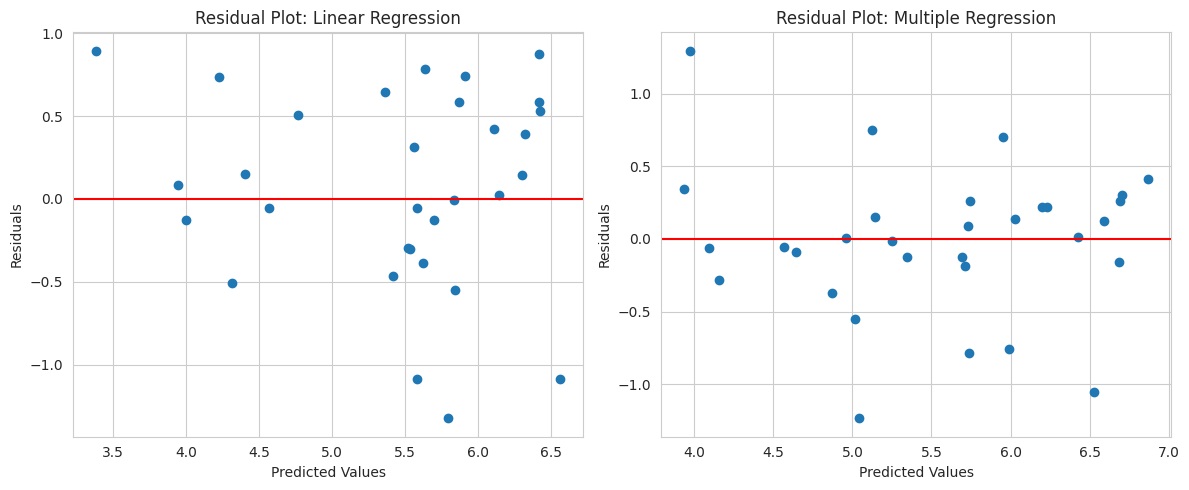

In [ ]:
residuals_linear= Y_test-y_pred_linear
residuals_multi=Y_test- y_pred_multi
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_pred_linear, residuals_linear)
plt.axhline(0, color='red')
plt.title("Residual Plot: Linear Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.subplot(1,2,2)
plt.scatter(y_pred_multi, residuals_multi)
plt.axhline(0, color='red')
plt.title("Residual Plot: Multiple Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

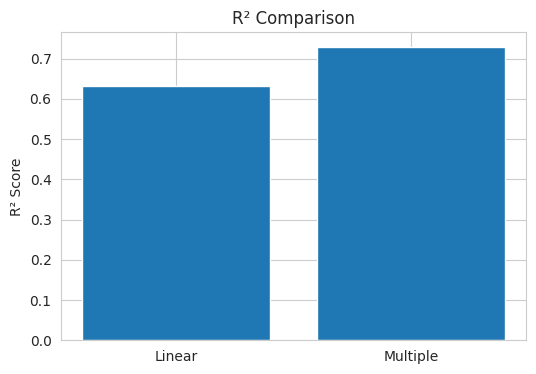

In [ ]:
r2_values=[model_r2,multi_model_r2]
labels=['Linear','Multiple']
plt.figure(figsize=(6,4))
plt.bar(labels, r2_values)
plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.show()
